In [2]:

%load_ext autoreload
%autoreload 2
import numpy as np
import matplotlib.pyplot as plt
from coffea import util
from coffea.processor import accumulate
import os
import re
import pandas as pd
import hist
import matplotlib as mpl
import mplhep
import sys
import json
import boost_histogram as bh
import uproot
from scipy.stats import beta
import hist
import hist.intervals
import awkward as ak

sys.path.append("../analysisTools/")
import plotTools as ptools
import utils

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [8]:
with open('../configs/sample_configs/signal_2022_Mchi_10_30_50_aEM.json') as file2022:
    sig_file_2022 = json.load(file2022)

with open('../configs/sample_configs/signal_2018_official_GEDidMVA90WP_aEM.json') as file2018:
    sig_file_2018 = json.load(file2018)


In [12]:
loc = sig_file_2022[0]["location"]
sig_root = uproot.open(loc)
sig_root.keys()
ntuple = sig_root["ntuples/outT"]

loc_2018 = sig_file_2018[1]["location"]
# sig_root_2018 = uproot.open(loc_2018)
# ntuple_2018 = sig_root_2018["ntuples/outT"]

In [7]:
gen_ele_vxy=ntuple["GenEle_vxy"].array()
print ("gen_ele_vxy:",gen_ele_vxy)  

gen_pos_vxy=ntuple["GenPos_vxy"].array()
print ("gen_pos_vxy:",gen_pos_vxy)  

gen_ele_vxy=ntuple["GenEle_vxy"].array()
print ("gen_ele_vxy:",gen_ele_vxy)  

gen_pos_vxy=ntuple["GenPos_vxy"].array()
print ("gen_pos_vxy:",gen_pos_vxy)  

gen_ele_vxy: [0.101, 0.102, 0.101, 0.102, 0.101, 0.101, ... 0.102, 0.0999, 0.1, 0.1, 0.101, 0.102]
gen_pos_vxy: [0.101, 0.102, 0.101, 0.102, 0.101, 0.101, ... 0.102, 0.0999, 0.1, 0.1, 0.101, 0.102]


In [35]:
gen_ele_pt=ntuple["GenEle_pt"].array()
print (gen_ele_pt)  

bins = np.linspace(0,50,50)

counts_perbin_genelept, bins_den  = np.histogram(gen_ele_pt, bins)
print("counts_perbin_genelept=", counts_perbin_genelept)
print ("bins:", bins_den)

[3.44, 0.0407, 4.56, 1.46, 2.26, 0.281, ... 1.21, 3.22, 1.53, 2.41, 4.34, 0.132]
counts_perbin_genelept= [19305 14681  9753  6416  4332  3078  2108  1485  1022   697   491   328
   223   146   100    64    54    41    29    29    18    13    17    10
     6     5     3     5     1     3     2     2     3     1     2     0
     1     2     1     5     1     0     1     0     0     0     0     0
     0]
bins: [ 0.          1.02040816  2.04081633  3.06122449  4.08163265  5.10204082
  6.12244898  7.14285714  8.16326531  9.18367347 10.20408163 11.2244898
 12.24489796 13.26530612 14.28571429 15.30612245 16.32653061 17.34693878
 18.36734694 19.3877551  20.40816327 21.42857143 22.44897959 23.46938776
 24.48979592 25.51020408 26.53061224 27.55102041 28.57142857 29.59183673
 30.6122449  31.63265306 32.65306122 33.67346939 34.69387755 35.71428571
 36.73469388 37.75510204 38.7755102  39.79591837 40.81632653 41.83673469
 42.85714286 43.87755102 44.89795918 45.91836735 46.93877551 47.95918367
 48.97

Text(1, 0, 'Gen_Ele_pT (in GeV)')

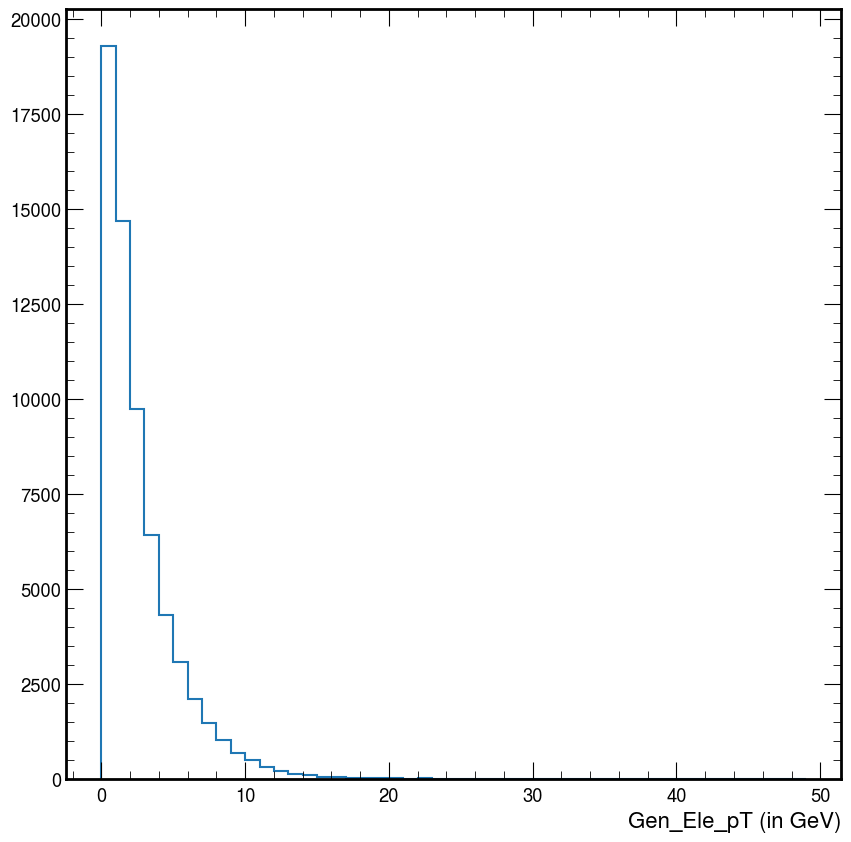

In [23]:
#Denominator
fig, ax = plt.subplots()
mplhep.histplot(counts_perbin_genelept)
ax.set_xlabel("Gen_Ele_pT (in GeV)")


In [44]:
maybe_num = ntuple["Electron_pt"].array()
new = ak.flatten(maybe_num)
new

<Array [13.3, 5.68, 13.7, ... 5.05, 5.92, 7.78] type='5583 * float32'>

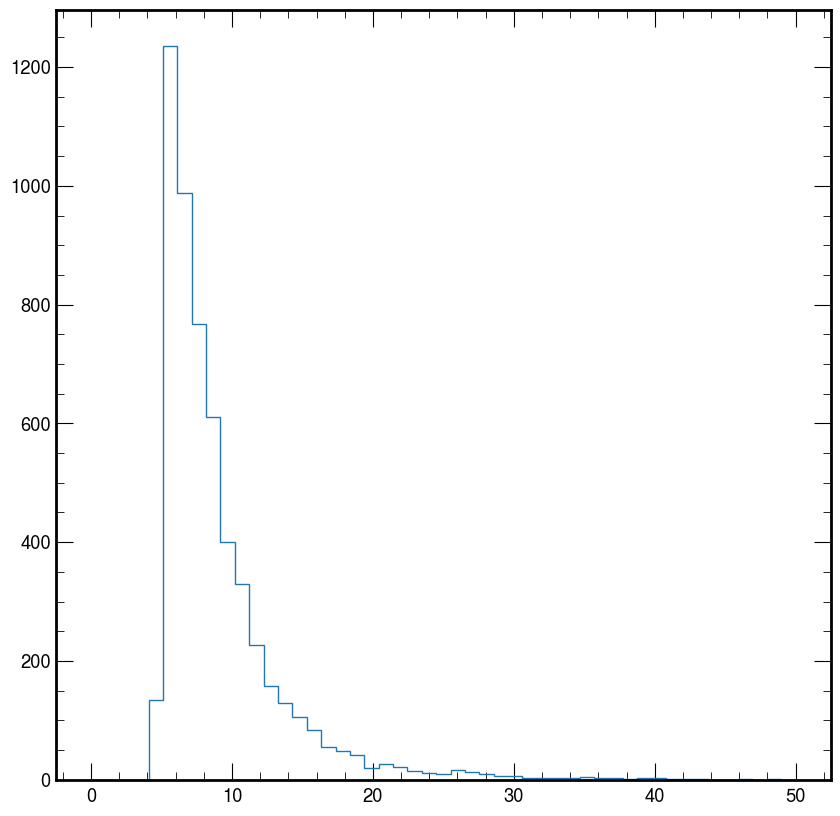

In [45]:
h1 = plt.hist(new,bins=bins,histtype='step')